##COMP 569
###Steam Review Sentiment Classification
Full Deep Learning Pipeline: BERT / RoBERTa / DistilBERT


In [1]:
#install dependencies
!pip install -q transformers datasets accelerate optuna scikit-learn matplotlib seaborn

In [2]:
from google.colab import files
import os

os.makedirs('./data/processed', exist_ok=True)

# This opens a file picker — select train.csv, val.csv, test.csv
uploaded = files.upload()

# Move them into place
for filename in uploaded:
    os.rename(filename, f'./data/processed/{filename}')

print(os.listdir('./data/processed'))

Saving test.csv to test.csv
Saving train.csv to train.csv
Saving val.csv to val.csv
['train.csv', 'test.csv', 'val.csv']


##Run once per Colab session

In [3]:
# !pip install -q transformers datasets accelerate optuna scikit-learn matplotlib seaborn

import os, sys, json, time, random, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)

warnings.filterwarnings("ignore")

##CONFIG & REPRODUCIBILITY

In [4]:
SEED = 42
MAX_LEN = 128
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


##LOADING

In [5]:
# If running in Colab, upload your CSVs or mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/CS569/data/processed")

DATA_DIR = Path("./data/processed")  # adjust to your path

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

# Fill NaN reviews
for df in [train_df, val_df, test_df]:
    df["review"] = df["review"].fillna("")

# Print class distribution
print("=== Class Distribution ===")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = df["voted_up"].value_counts()
    print(f"{name}: {len(df)} rows | Pos: {counts.get(1,0)} ({counts.get(1,0)/len(df)*100:.1f}%) | Neg: {counts.get(0,0)} ({counts.get(0,0)/len(df)*100:.1f}%)")

=== Class Distribution ===
Train: 8000 rows | Pos: 7740 (96.8%) | Neg: 260 (3.2%)
Val: 1000 rows | Pos: 965 (96.5%) | Neg: 35 (3.5%)
Test: 1000 rows | Pos: 959 (95.9%) | Neg: 41 (4.1%)


##DATASET CLASS

In [6]:
METADATA_COLS = ["votes_up", "votes_funny", "weighted_vote_score",
                 "comment_count", "steam_purchase", "received_for_free",
                 "written_during_early_access"]

class SteamReviewDataset(Dataset):
    """Tokenizes reviews and optionally includes metadata features."""

    def __init__(self, dataframe, tokenizer, max_len=MAX_LEN, include_metadata=False):
        self.texts = dataframe["review"].tolist()
        self.labels = dataframe["voted_up"].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.include_metadata = include_metadata

        if include_metadata:
            meta = dataframe[METADATA_COLS].fillna(0).values.astype(np.float32)
            # Normalize metadata (z-score per column)
            self.meta_mean = meta.mean(axis=0)
            self.meta_std  = meta.std(axis=0) + 1e-8
            self.metadata  = (meta - self.meta_mean) / self.meta_std
        else:
            self.metadata = None

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        item = {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.float)
        }
        if self.metadata is not None:
            item["metadata"] = torch.tensor(self.metadata[idx], dtype=torch.float)
        return item

##FOCAL LOSS (for class imbalance)

In [7]:
class FocalLoss(nn.Module):
    """Focal Loss: down-weights easy (majority) examples."""
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_weight = alpha_t * (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()

##MODEL ARCHITECTURES

In [8]:
class BERTClassifier(nn.Module):
    """Standard BERT binary classifier with optional metadata fusion."""
    def __init__(self, model_name="bert-base-uncased", dropout=0.3,
                 include_metadata=False, n_meta_features=0):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.include_metadata = include_metadata

        if include_metadata and n_meta_features > 0:
            # Feature Fusion: concat [CLS] embedding + metadata
            self.meta_proj = nn.Sequential(
                nn.Linear(n_meta_features, 32),
                nn.ReLU(),
                nn.Dropout(0.2)
            )
            self.classifier = nn.Linear(hidden_size + 32, 1)
        else:
            self.meta_proj = None
            self.classifier = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask, metadata=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        cls_emb = self.dropout(cls_emb)

        if self.include_metadata and metadata is not None and self.meta_proj is not None:
            meta_emb = self.meta_proj(metadata)
            combined = torch.cat([cls_emb, meta_emb], dim=1)
            logits = self.classifier(combined)
        else:
            logits = self.classifier(cls_emb)

        return logits.squeeze(-1)

##TRAINING ENGINE

In [9]:
class TrainingEngine:
    """Handles training loop, evaluation, early stopping, checkpointing."""

    def __init__(self, model, train_loader, val_loader, optimizer, scheduler,
                 criterion, device, scaler=None, patience=3, experiment_name="exp"):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.criterion = criterion
        self.device = device
        self.scaler = scaler
        self.patience = patience
        self.experiment_name = experiment_name

        self.history = {"train_loss": [], "val_loss": [],
                        "val_f1": [], "val_recall_neg": [], "val_auc": [],
                        "lr": []}
        self.best_val_f1 = 0
        self.patience_counter = 0

    def train_epoch(self):
        self.model.train()
        total_loss = 0
        for batch in self.train_loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["label"].to(self.device)
            metadata = batch.get("metadata")
            if metadata is not None:
                metadata = metadata.to(self.device)

            self.optimizer.zero_grad()

            if self.scaler:
                with autocast():
                    logits = self.model(input_ids, attention_mask, metadata)
                    loss = self.criterion(logits, labels)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                logits = self.model(input_ids, attention_mask, metadata)
                loss = self.criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()

            self.scheduler.step()
            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    @torch.no_grad()
    def evaluate(self, loader=None):
        if loader is None:
            loader = self.val_loader
        self.model.eval()
        all_logits, all_labels = [], []
        total_loss = 0

        for batch in loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["label"].to(self.device)
            metadata = batch.get("metadata")
            if metadata is not None:
                metadata = metadata.to(self.device)

            logits = self.model(input_ids, attention_mask, metadata)
            loss = self.criterion(logits, labels)
            total_loss += loss.item()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)
        probs = torch.sigmoid(all_logits).numpy()
        preds = (probs >= 0.5).astype(int)
        labels_np = all_labels.numpy().astype(int)

        metrics = {
            "loss": total_loss / len(loader),
            "accuracy": accuracy_score(labels_np, preds),
            "f1_macro": f1_score(labels_np, preds, average="macro"),
            "f1_neg": f1_score(labels_np, preds, pos_label=0, average="binary"),
            "report": classification_report(labels_np, preds, target_names=["Negative","Positive"], output_dict=True),
            "report_str": classification_report(labels_np, preds, target_names=["Negative","Positive"]),
            "confusion": confusion_matrix(labels_np, preds),
            "probs": probs,
            "preds": preds,
            "labels": labels_np
        }
        try:
            metrics["auc"] = roc_auc_score(labels_np, probs)
        except ValueError:
            metrics["auc"] = 0.0

        return metrics

    def train(self, n_epochs):
        print(f"\n{'='*60}")
        print(f"Training: {self.experiment_name}")
        print(f"{'='*60}")

        for epoch in range(1, n_epochs + 1):
            t0 = time.time()
            train_loss = self.train_epoch()
            val_metrics = self.evaluate()

            elapsed = time.time() - t0
            lr = self.optimizer.param_groups[0]["lr"]

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_metrics["loss"])
            self.history["val_f1"].append(val_metrics["f1_macro"])
            self.history["val_recall_neg"].append(val_metrics["report"]["Negative"]["recall"])
            self.history["val_auc"].append(val_metrics["auc"])
            self.history["lr"].append(lr)

            print(f"Epoch {epoch}/{n_epochs} ({elapsed:.0f}s) | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
                  f"Val F1: {val_metrics['f1_macro']:.4f} | "
                  f"Neg Recall: {val_metrics['report']['Negative']['recall']:.4f} | "
                  f"AUC: {val_metrics['auc']:.4f}")

            # Early stopping on val F1 (macro)
            if val_metrics["f1_macro"] > self.best_val_f1:
                self.best_val_f1 = val_metrics["f1_macro"]
                self.patience_counter = 0
                torch.save(self.model.state_dict(),
                           OUTPUT_DIR / f"{self.experiment_name}_best.pt")
                print(f"  -> Saved best model (F1={self.best_val_f1:.4f})")
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.patience:
                    print(f"  -> Early stopping at epoch {epoch}")
                    break

        # Load best checkpoint
        self.model.load_state_dict(
            torch.load(OUTPUT_DIR / f"{self.experiment_name}_best.pt", weights_only=True))
        return self.history

##PLOTTING UTILITIES

In [10]:
def plot_training_curves(history, experiment_name):
    """Plot train/val loss and metrics over epochs."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], "r-o", label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss"); axes[0].legend()

    axes[1].plot(epochs, history["val_f1"], "g-o", label="Val F1 (Macro)")
    axes[1].plot(epochs, history["val_recall_neg"], "m-o", label="Neg Class Recall")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].set_title("Validation Metrics"); axes[1].legend()

    axes[2].plot(epochs, history["val_auc"], "c-o", label="Val AUC")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("AUC")
    axes[2].set_title("Validation ROC-AUC"); axes[2].legend()

    plt.suptitle(experiment_name, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{experiment_name}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_confusion_matrix(cm, experiment_name):
    """Plot confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {experiment_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{experiment_name}_cm.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_roc_curve(labels, probs, experiment_name):
    """Plot ROC curve."""
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val = roc_auc_score(labels, probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, "b-", label=f"AUC = {auc_val:.4f}")
    ax.plot([0,1], [0,1], "k--", alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {experiment_name}"); ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{experiment_name}_roc.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_precision_recall_curve(labels, probs, experiment_name):
    """Plot Precision-Recall curve for the negative class."""
    # Invert for negative class
    precision, recall, _ = precision_recall_curve(1 - labels, 1 - probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, "r-")
    ax.set_xlabel("Recall (Negative)"); ax.set_ylabel("Precision (Negative)")
    ax.set_title(f"Precision-Recall (Neg Class) — {experiment_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{experiment_name}_pr.png", dpi=150, bbox_inches="tight")
    plt.show()

##HELPER: run a full experiment

In [11]:
def run_experiment(model_name, experiment_name, train_df, val_df,
                   loss_type="focal", lr=2e-5, batch_size=16,
                   dropout=0.3, epochs=5, patience=3,
                   include_metadata=False, max_len=128):
    """Run a complete training experiment and return results."""

    print(f"\n{'#'*60}")
    print(f"# Experiment: {experiment_name}")
    print(f"# Model: {model_name} | LR: {lr} | BS: {batch_size}")
    print(f"# Loss: {loss_type} | Dropout: {dropout} | MaxLen: {max_len}")
    print(f"# Metadata: {include_metadata}")
    print(f"{'#'*60}")

    # Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Datasets
    train_ds = SteamReviewDataset(train_df, tokenizer, max_len, include_metadata)
    val_ds   = SteamReviewDataset(val_df,   tokenizer, max_len, include_metadata)

    # Weighted sampler to oversample minority class during training
    class_counts = np.bincount(train_df["voted_up"].values)
    weights = 1.0 / class_counts
    sample_weights = weights[train_df["voted_up"].values]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    # Model
    n_meta = len(METADATA_COLS) if include_metadata else 0
    model = BERTClassifier(model_name, dropout, include_metadata, n_meta).to(device)

    # Loss
    if loss_type == "focal":
        criterion = FocalLoss(alpha=0.75, gamma=2.0)
    elif loss_type == "weighted_bce":
        pos_weight = torch.tensor([class_counts[1] / class_counts[0]]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    # Optimizer & Scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = GradScaler() if torch.cuda.is_available() else None

    # Train
    engine = TrainingEngine(model, train_loader, val_loader, optimizer, scheduler,
                            criterion, device, scaler, patience, experiment_name)
    history = engine.train(epochs)

    # Final val evaluation
    val_metrics = engine.evaluate()

    # Plots
    plot_training_curves(history, experiment_name)
    plot_confusion_matrix(val_metrics["confusion"], experiment_name)
    plot_roc_curve(val_metrics["labels"], val_metrics["probs"], experiment_name)
    plot_precision_recall_curve(val_metrics["labels"], val_metrics["probs"], experiment_name)

    print(f"\n--- {experiment_name} Final Validation Report ---")
    print(val_metrics["report_str"])
    print(f"AUC: {val_metrics['auc']:.4f}")

    return {
        "experiment": experiment_name,
        "model_name": model_name,
        "history": history,
        "val_metrics": val_metrics,
        "config": {"lr": lr, "batch_size": batch_size, "dropout": dropout,
                   "loss": loss_type, "max_len": max_len, "metadata": include_metadata}
    }



##EXPERIMENT 1: BERT BASELINE (with Focal Loss)


############################################################
# Experiment: bert_focal
# Model: bert-base-uncased | LR: 2e-05 | BS: 16
# Loss: focal | Dropout: 0.3 | MaxLen: 128
# Metadata: False
############################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: bert_focal
Epoch 1/5 (80s) | Train Loss: 0.0510 | Val Loss: 0.0506 | Val F1: 0.5298 | Neg Recall: 0.3143 | AUC: 0.6886
  -> Saved best model (F1=0.5298)
Epoch 2/5 (72s) | Train Loss: 0.0143 | Val Loss: 0.0409 | Val F1: 0.5412 | Neg Recall: 0.1429 | AUC: 0.7035
  -> Saved best model (F1=0.5412)
Epoch 3/5 (70s) | Train Loss: 0.0070 | Val Loss: 0.0393 | Val F1: 0.5445 | Neg Recall: 0.0857 | AUC: 0.6964
  -> Saved best model (F1=0.5445)
Epoch 4/5 (70s) | Train Loss: 0.0032 | Val Loss: 0.0409 | Val F1: 0.5293 | Neg Recall: 0.0571 | AUC: 0.6567
Epoch 5/5 (70s) | Train Loss: 0.0021 | Val Loss: 0.0429 | Val F1: 0.5407 | Neg Recall: 0.0857 | AUC: 0.6654


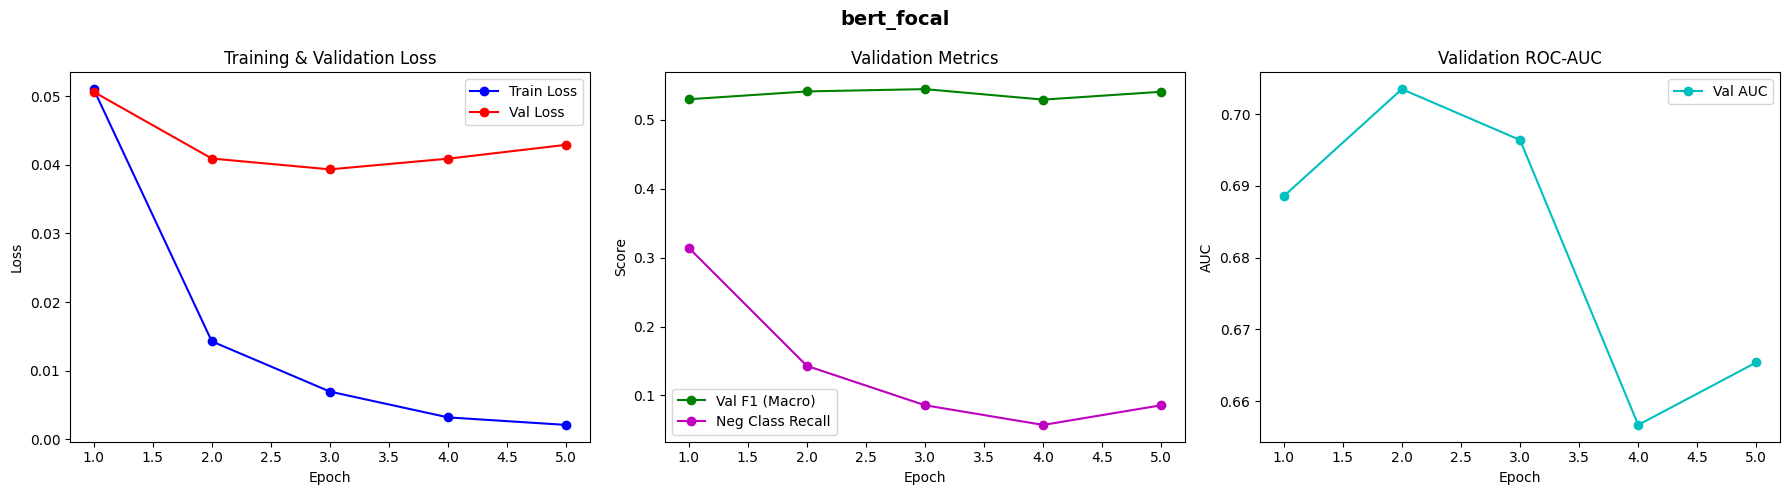

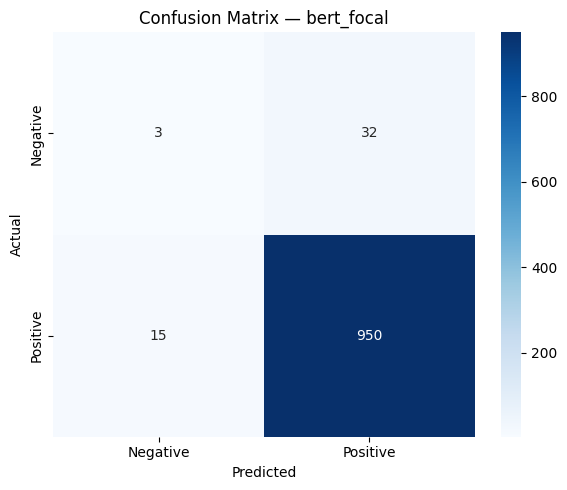

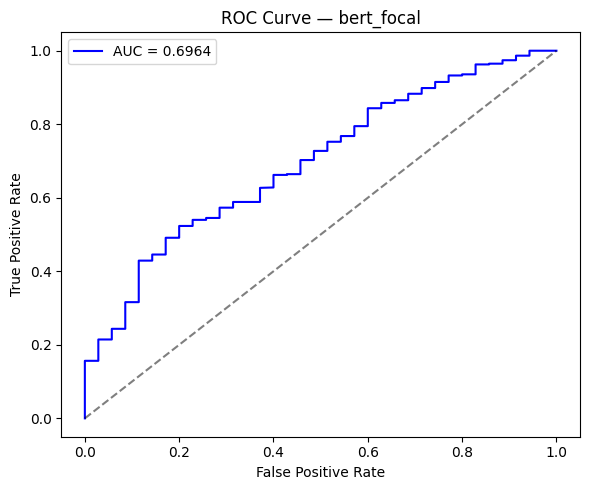

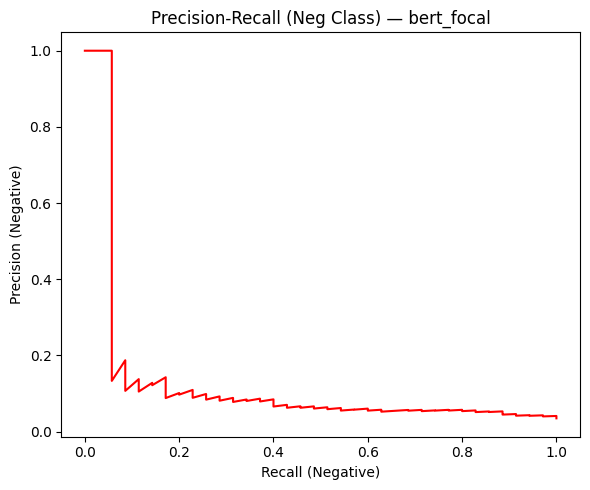


--- bert_focal Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.17      0.09      0.11        35
    Positive       0.97      0.98      0.98       965

    accuracy                           0.95      1000
   macro avg       0.57      0.54      0.54      1000
weighted avg       0.94      0.95      0.95      1000

AUC: 0.6964


In [12]:
results = {}

results["bert_focal"] = run_experiment(
    model_name="bert-base-uncased",
    experiment_name="bert_focal",
    train_df=train_df, val_df=val_df,
    loss_type="focal", lr=2e-5, batch_size=16,
    dropout=0.3, epochs=5, patience=3
)

##EXPERIMENT 2: BERT with Weighted BCE (comparison)


############################################################
# Experiment: bert_wbce
# Model: bert-base-uncased | LR: 2e-05 | BS: 16
# Loss: weighted_bce | Dropout: 0.3 | MaxLen: 128
# Metadata: False
############################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: bert_wbce
Epoch 1/5 (70s) | Train Loss: 2.4982 | Val Loss: 4.9445 | Val F1: 0.5567 | Neg Recall: 0.2857 | AUC: 0.6743
  -> Saved best model (F1=0.5567)
Epoch 2/5 (70s) | Train Loss: 1.4456 | Val Loss: 5.7507 | Val F1: 0.5452 | Neg Recall: 0.1714 | AUC: 0.7217
Epoch 3/5 (70s) | Train Loss: 1.0407 | Val Loss: 4.0699 | Val F1: 0.5299 | Neg Recall: 0.0857 | AUC: 0.6806
Epoch 4/5 (70s) | Train Loss: 0.5714 | Val Loss: 2.7414 | Val F1: 0.5261 | Neg Recall: 0.0571 | AUC: 0.6991
  -> Early stopping at epoch 4


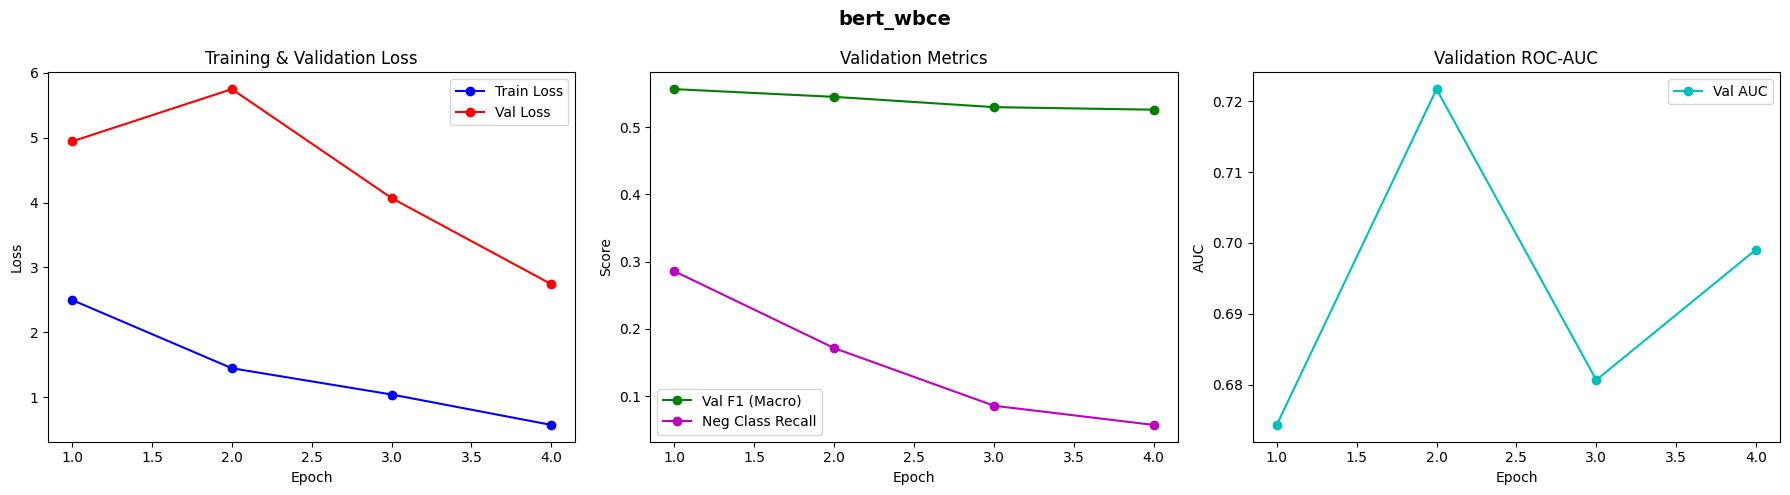

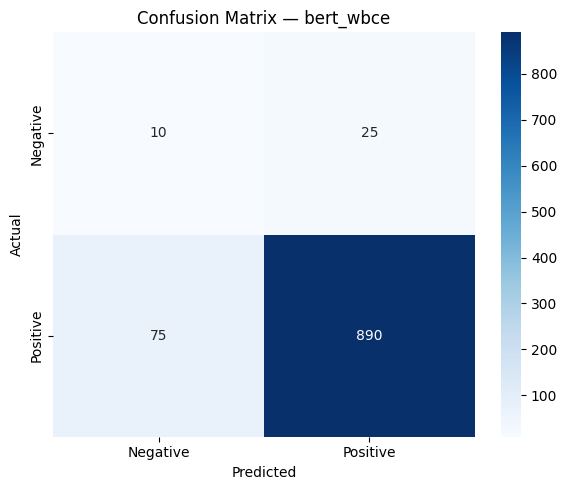

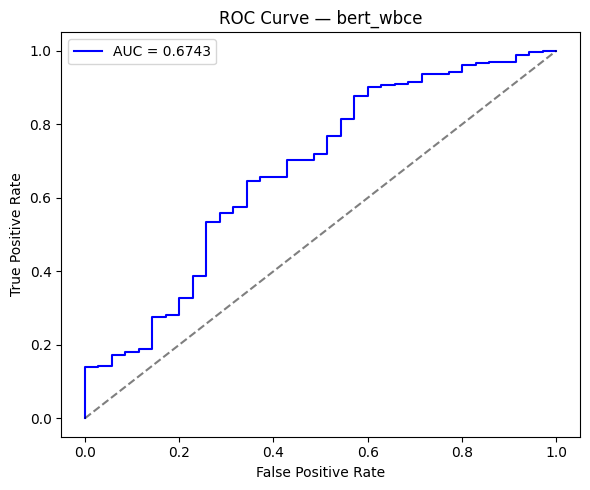

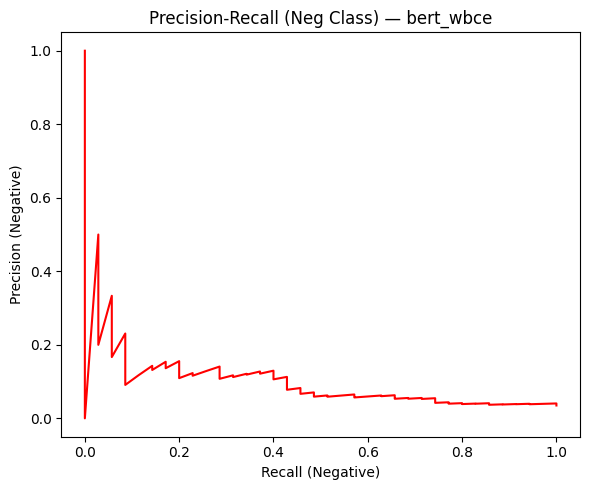


--- bert_wbce Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.12      0.29      0.17        35
    Positive       0.97      0.92      0.95       965

    accuracy                           0.90      1000
   macro avg       0.55      0.60      0.56      1000
weighted avg       0.94      0.90      0.92      1000

AUC: 0.6743


In [13]:
results["bert_wbce"] = run_experiment(
    model_name="bert-base-uncased",
    experiment_name="bert_wbce",
    train_df=train_df, val_df=val_df,
    loss_type="weighted_bce", lr=2e-5, batch_size=16,
    dropout=0.3, epochs=5, patience=3
)

##EXPERIMENT 3: RoBERTa


############################################################
# Experiment: roberta_focal
# Model: roberta-base | LR: 2e-05 | BS: 16
# Loss: focal | Dropout: 0.3 | MaxLen: 128
# Metadata: False
############################################################


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training: roberta_focal
Epoch 1/5 (73s) | Train Loss: 0.0617 | Val Loss: 0.0427 | Val F1: 0.5646 | Neg Recall: 0.3143 | AUC: 0.7455
  -> Saved best model (F1=0.5646)
Epoch 2/5 (73s) | Train Loss: 0.0250 | Val Loss: 0.0487 | Val F1: 0.6012 | Neg Recall: 0.3143 | AUC: 0.6693
  -> Saved best model (F1=0.6012)
Epoch 3/5 (83s) | Train Loss: 0.0118 | Val Loss: 0.0438 | Val F1: 0.5372 | Neg Recall: 0.0857 | AUC: 0.7422
Epoch 4/5 (74s) | Train Loss: 0.0055 | Val Loss: 0.0764 | Val F1: 0.5703 | Neg Recall: 0.2000 | AUC: 0.7105
Epoch 5/5 (74s) | Train Loss: 0.0040 | Val Loss: 0.0581 | Val F1: 0.5821 | Neg Recall: 0.1714 | AUC: 0.6998
  -> Early stopping at epoch 5


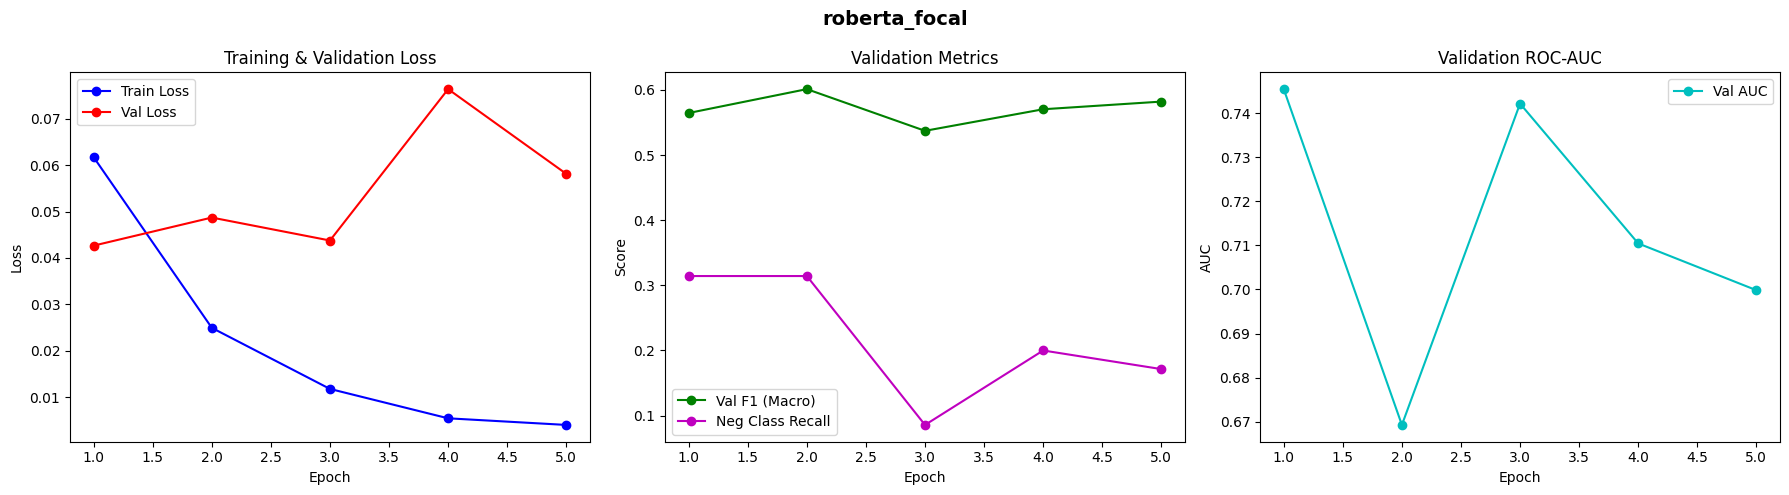

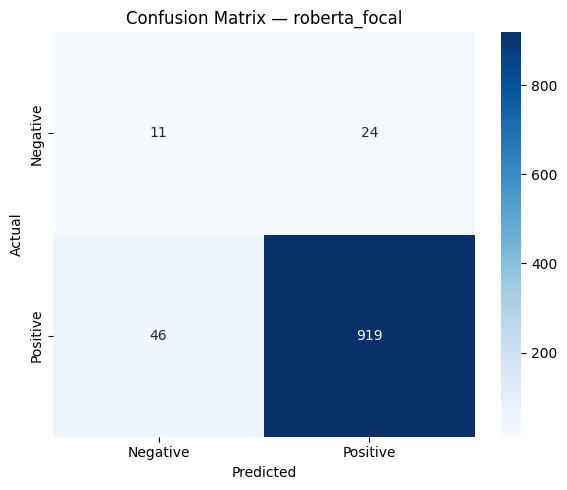

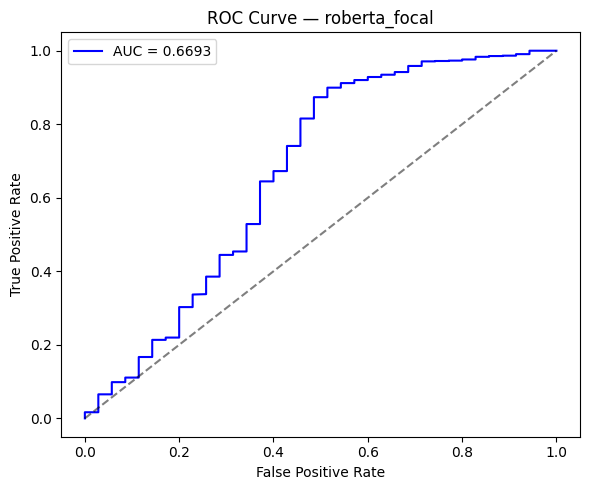

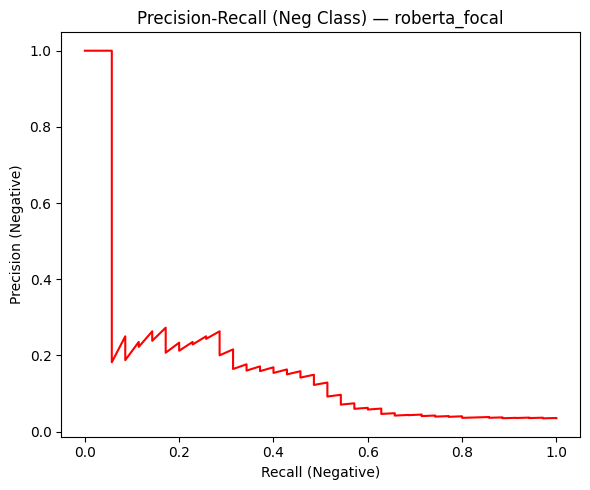


--- roberta_focal Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.19      0.31      0.24        35
    Positive       0.97      0.95      0.96       965

    accuracy                           0.93      1000
   macro avg       0.58      0.63      0.60      1000
weighted avg       0.95      0.93      0.94      1000

AUC: 0.6693


In [14]:
results["roberta_focal"] = run_experiment(
    model_name="roberta-base",
    experiment_name="roberta_focal",
    train_df=train_df, val_df=val_df,
    loss_type="focal", lr=2e-5, batch_size=16,
    dropout=0.3, epochs=5, patience=3
)

##EXPERIMENT 4: DistilBERT


############################################################
# Experiment: distilbert_focal
# Model: distilbert-base-uncased | LR: 2e-05 | BS: 16
# Loss: focal | Dropout: 0.3 | MaxLen: 128
# Metadata: False
############################################################


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: distilbert_focal
Epoch 1/5 (40s) | Train Loss: 0.0527 | Val Loss: 0.0404 | Val F1: 0.5682 | Neg Recall: 0.2857 | AUC: 0.7247
  -> Saved best model (F1=0.5682)
Epoch 2/5 (40s) | Train Loss: 0.0130 | Val Loss: 0.0391 | Val F1: 0.5533 | Neg Recall: 0.1143 | AUC: 0.6789
Epoch 3/5 (38s) | Train Loss: 0.0041 | Val Loss: 0.0510 | Val F1: 0.5444 | Neg Recall: 0.1143 | AUC: 0.6532
Epoch 4/5 (38s) | Train Loss: 0.0027 | Val Loss: 0.0446 | Val F1: 0.5445 | Neg Recall: 0.0857 | AUC: 0.6246
  -> Early stopping at epoch 4


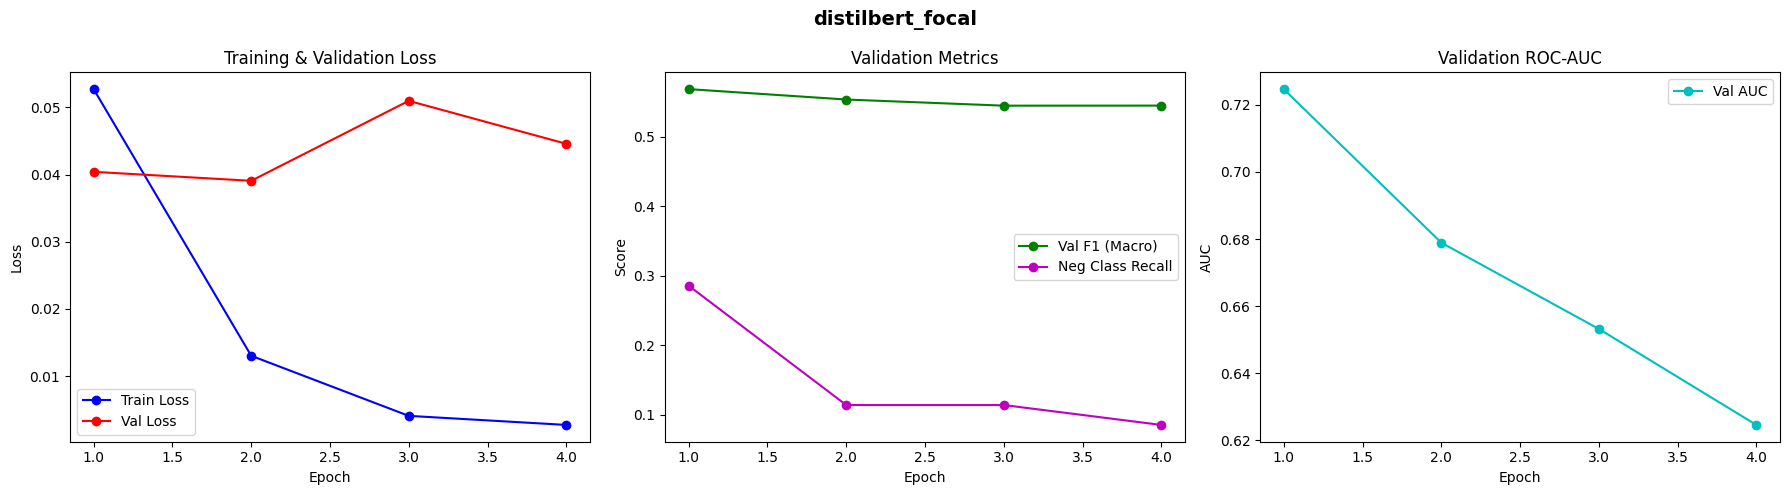

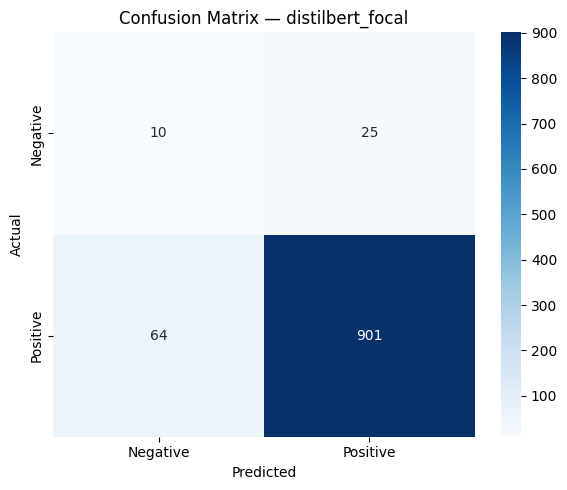

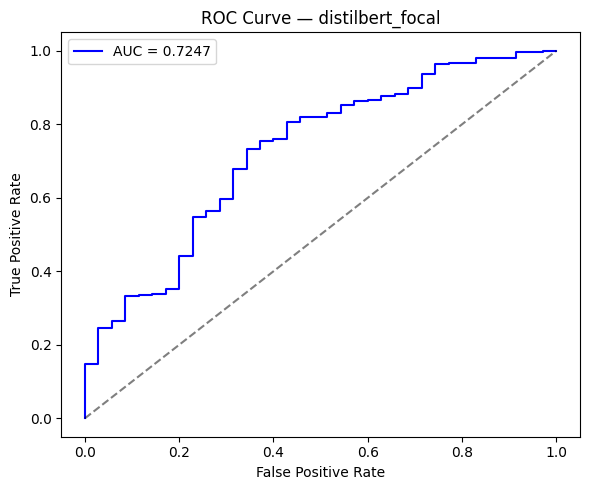

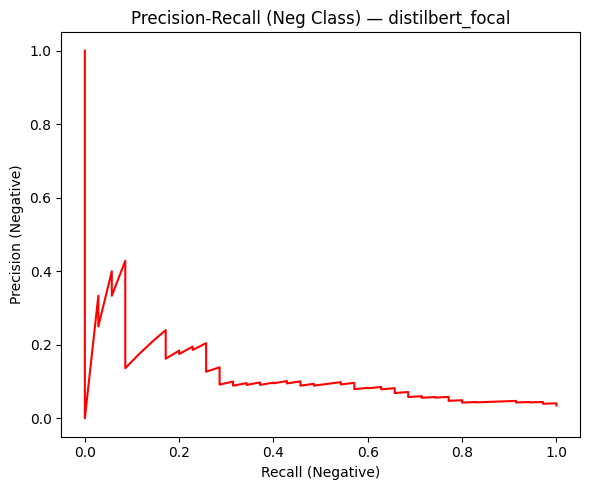


--- distilbert_focal Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.14      0.29      0.18        35
    Positive       0.97      0.93      0.95       965

    accuracy                           0.91      1000
   macro avg       0.55      0.61      0.57      1000
weighted avg       0.94      0.91      0.93      1000

AUC: 0.7247


In [15]:
results["distilbert_focal"] = run_experiment(
    model_name="distilbert-base-uncased",
    experiment_name="distilbert_focal",
    train_df=train_df, val_df=val_df,
    loss_type="focal", lr=2e-5, batch_size=16,
    dropout=0.3, epochs=5, patience=3
)

##EXPERIMENT 5: BERT + Feature Fusion (Text + Metadata)


############################################################
# Experiment: bert_fusion
# Model: bert-base-uncased | LR: 2e-05 | BS: 16
# Loss: focal | Dropout: 0.3 | MaxLen: 128
# Metadata: True
############################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: bert_fusion
Epoch 1/5 (71s) | Train Loss: 0.0501 | Val Loss: 0.0469 | Val F1: 0.5488 | Neg Recall: 0.2571 | AUC: 0.7019
  -> Saved best model (F1=0.5488)
Epoch 2/5 (70s) | Train Loss: 0.0134 | Val Loss: 0.0474 | Val F1: 0.5849 | Neg Recall: 0.2286 | AUC: 0.7037
  -> Saved best model (F1=0.5849)
Epoch 3/5 (71s) | Train Loss: 0.0059 | Val Loss: 0.0493 | Val F1: 0.5165 | Neg Recall: 0.0571 | AUC: 0.6821
Epoch 4/5 (71s) | Train Loss: 0.0030 | Val Loss: 0.0533 | Val F1: 0.5372 | Neg Recall: 0.0857 | AUC: 0.6858
Epoch 5/5 (71s) | Train Loss: 0.0025 | Val Loss: 0.0492 | Val F1: 0.5293 | Neg Recall: 0.0571 | AUC: 0.6611
  -> Early stopping at epoch 5


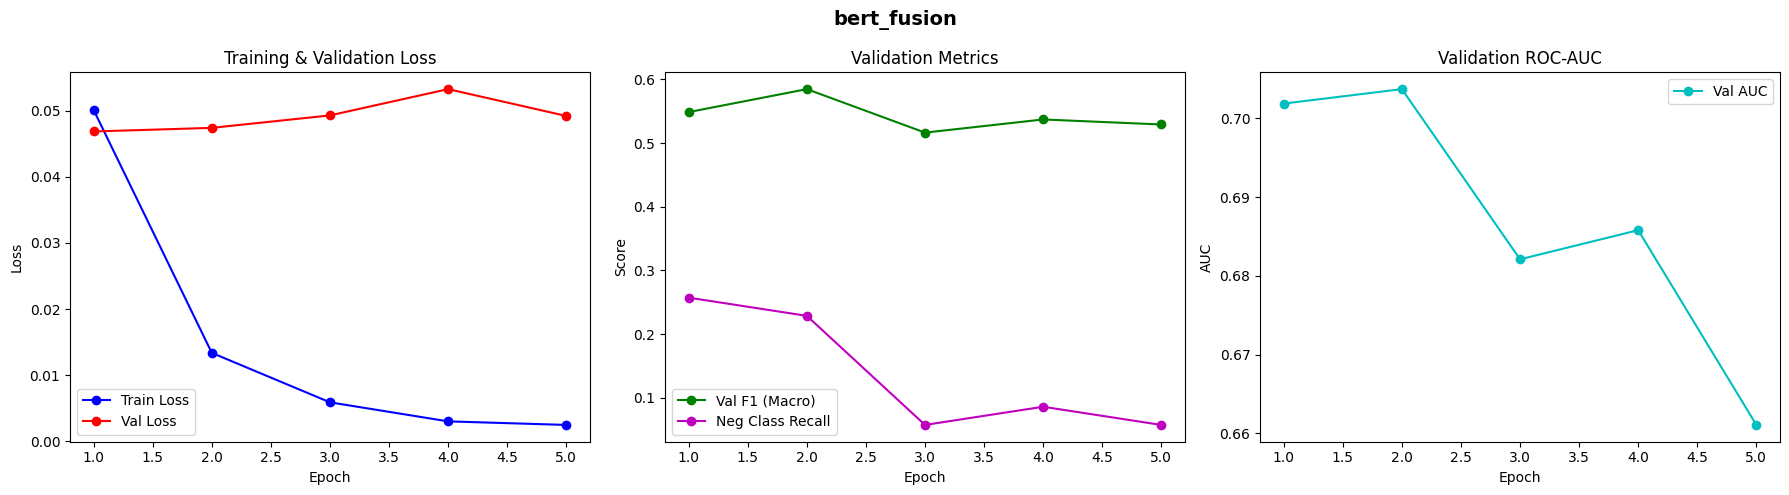

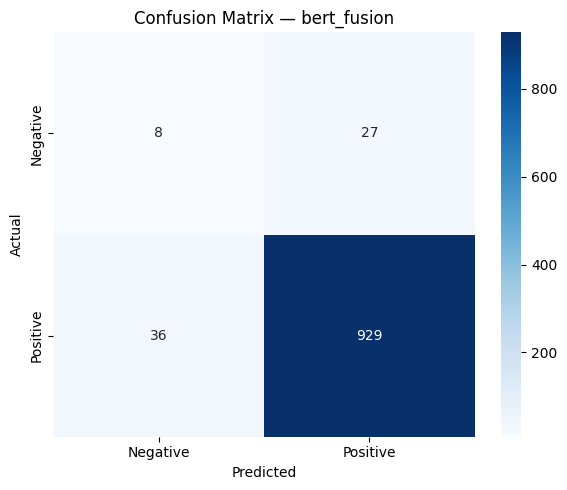

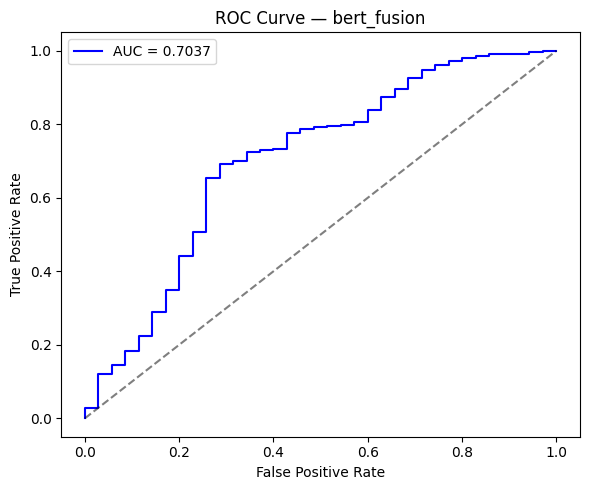

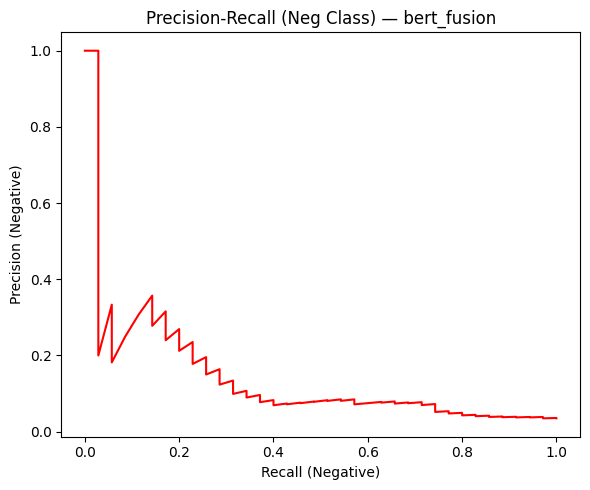


--- bert_fusion Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.18      0.23      0.20        35
    Positive       0.97      0.96      0.97       965

    accuracy                           0.94      1000
   macro avg       0.58      0.60      0.58      1000
weighted avg       0.94      0.94      0.94      1000

AUC: 0.7037


In [16]:
results["bert_fusion"] = run_experiment(
    model_name="bert-base-uncased",
    experiment_name="bert_fusion",
    train_df=train_df, val_df=val_df,
    loss_type="focal", lr=2e-5, batch_size=16,
    dropout=0.3, epochs=5, patience=3,
    include_metadata=True
)


##HYPERPARAMETER TUNING WITH OPTUNA

[I 2026-04-20 00:24:48,313] A new study created in memory with name: bert_hparam_search


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: optuna_trial_0
Epoch 1/4 (146s) | Train Loss: 2.9194 | Val Loss: 11.5471 | Val F1: 0.5558 | Neg Recall: 0.3714 | AUC: 0.7209
  -> Saved best model (F1=0.5558)
Epoch 2/4 (146s) | Train Loss: 2.1666 | Val Loss: 3.9970 | Val F1: 0.5400 | Neg Recall: 0.1143 | AUC: 0.7316
Epoch 3/4 (146s) | Train Loss: 1.1655 | Val Loss: 3.1968 | Val F1: 0.5576 | Neg Recall: 0.1143 | AUC: 0.7264
  -> Saved best model (F1=0.5576)
Epoch 4/4 (146s) | Train Loss: 0.5345 | Val Loss: 2.0908 | Val F1: 0.5327 | Neg Recall: 0.0571 | AUC: 0.7078


[I 2026-04-20 00:34:57,951] Trial 0 finished with value: 0.5575660716381794 and parameters: {'lr': 3.078705982422741e-05, 'dropout': 0.30000000000000004, 'batch_size': 8, 'max_len': 256, 'loss_type': 'weighted_bce'}. Best is trial 0 with value: 0.5575660716381794.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: optuna_trial_9
Epoch 1/4 (147s) | Train Loss: 2.9509 | Val Loss: 18.5388 | Val F1: 0.5184 | Neg Recall: 0.4000 | AUC: 0.6581
  -> Saved best model (F1=0.5184)
Epoch 2/4 (147s) | Train Loss: 2.0937 | Val Loss: 4.2998 | Val F1: 0.5948 | Neg Recall: 0.2286 | AUC: 0.7037
  -> Saved best model (F1=0.5948)
Epoch 3/4 (147s) | Train Loss: 1.2384 | Val Loss: 2.8417 | Val F1: 0.5432 | Neg Recall: 0.0857 | AUC: 0.7102
Epoch 4/4 (146s) | Train Loss: 0.5532 | Val Loss: 3.1673 | Val F1: 0.5738 | Neg Recall: 0.1429 | AUC: 0.7007
  -> Early stopping at epoch 4


[I 2026-04-20 01:27:25,286] Trial 9 finished with value: 0.5947992123465391 and parameters: {'lr': 3.270363097787289e-05, 'dropout': 0.5, 'batch_size': 8, 'max_len': 256, 'loss_type': 'weighted_bce'}. Best is trial 9 with value: 0.5947992123465391.



=== OPTUNA BEST TRIAL ===
Best F1 (macro): 0.5948
Best params: {'lr': 3.270363097787289e-05, 'dropout': 0.5, 'batch_size': 8, 'max_len': 256, 'loss_type': 'weighted_bce'}


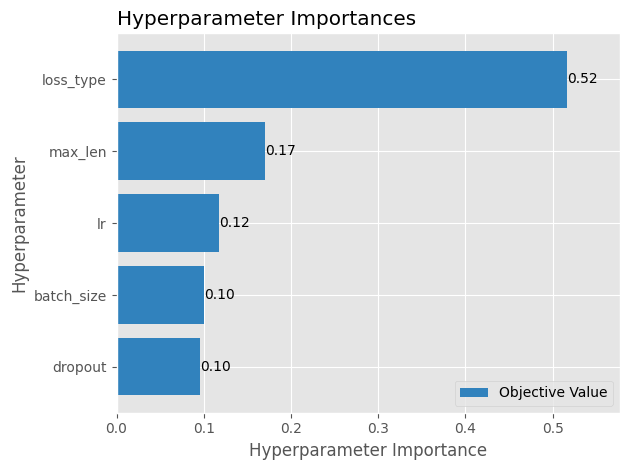

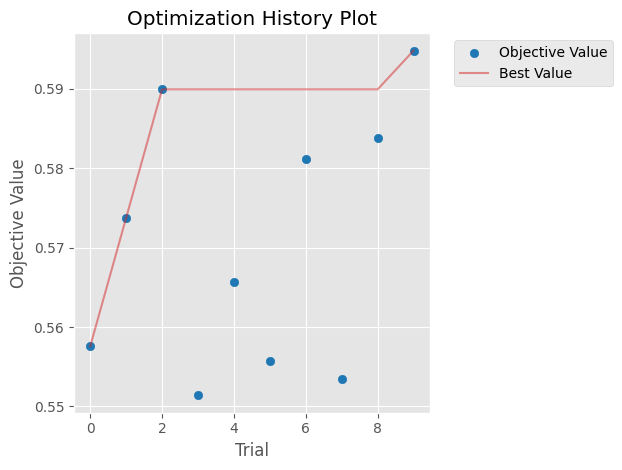

In [17]:
import optuna
from optuna.trial import Trial

def optuna_objective(trial: Trial):
    """Optuna objective function for BERT hyperparameter search."""
    lr        = trial.suggest_float("lr", 1e-5, 5e-5, log=True)
    dropout   = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    max_len   = trial.suggest_categorical("max_len", [128, 256])
    loss_type = trial.suggest_categorical("loss_type", ["focal", "weighted_bce"])

    set_seed()
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

    train_ds = SteamReviewDataset(train_df, tokenizer, max_len)
    val_ds   = SteamReviewDataset(val_df,   tokenizer, max_len)

    class_counts = np.bincount(train_df["voted_up"].values)
    weights = 1.0 / class_counts
    sample_weights = weights[train_df["voted_up"].values]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2)

    model = BERTClassifier("bert-base-uncased", dropout).to(device)

    if loss_type == "focal":
        criterion = FocalLoss(alpha=0.75, gamma=2.0)
    else:
        pos_weight = torch.tensor([class_counts[1] / class_counts[0]]).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    n_epochs = 4
    total_steps = len(train_loader) * n_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1*total_steps), total_steps)
    scaler = GradScaler() if torch.cuda.is_available() else None

    engine = TrainingEngine(model, train_loader, val_loader, optimizer, scheduler,
                            criterion, device, scaler, patience=2,
                            experiment_name=f"optuna_trial_{trial.number}")
    engine.train(n_epochs)
    val_metrics = engine.evaluate()

    return val_metrics["f1_macro"]

# Run 15 trials (takes ~30-45 min on T4)
study = optuna.create_study(direction="maximize", study_name="bert_hparam_search")
study.optimize(optuna_objective, n_trials=15, timeout=3600)

print("\n=== OPTUNA BEST TRIAL ===")
print(f"Best F1 (macro): {study.best_trial.value:.4f}")
print(f"Best params: {study.best_trial.params}")

# Save Optuna results
optuna_results = []
for t in study.trials:
    optuna_results.append({"trial": t.number, "value": t.value, **t.params})
pd.DataFrame(optuna_results).to_csv(OUTPUT_DIR / "optuna_results.csv", index=False)

# Optuna visualization
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_param_importance.png", dpi=150, bbox_inches="tight")
plt.show()

fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_history.png", dpi=150, bbox_inches="tight")
plt.show()

##BEST MODEL: Re-train with Optuna's best params


############################################################
# Experiment: bert_tuned_optuna
# Model: bert-base-uncased | LR: 3.270363097787289e-05 | BS: 8
# Loss: weighted_bce | Dropout: 0.5 | MaxLen: 256
# Metadata: False
############################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: bert_tuned_optuna
Epoch 1/5 (145s) | Train Loss: 2.6569 | Val Loss: 12.2734 | Val F1: 0.5395 | Neg Recall: 0.3143 | AUC: 0.7506
  -> Saved best model (F1=0.5395)
Epoch 2/5 (145s) | Train Loss: 2.3405 | Val Loss: 3.3035 | Val F1: 0.5534 | Neg Recall: 0.1429 | AUC: 0.7200
  -> Saved best model (F1=0.5534)
Epoch 3/5 (145s) | Train Loss: 1.1122 | Val Loss: 2.6314 | Val F1: 0.5793 | Neg Recall: 0.1429 | AUC: 0.6739
  -> Saved best model (F1=0.5793)
Epoch 4/5 (145s) | Train Loss: 0.9126 | Val Loss: 2.8730 | Val F1: 0.5445 | Neg Recall: 0.0857 | AUC: 0.7093
Epoch 5/5 (145s) | Train Loss: 0.2738 | Val Loss: 2.6774 | Val F1: 0.5517 | Neg Recall: 0.0857 | AUC: 0.6819


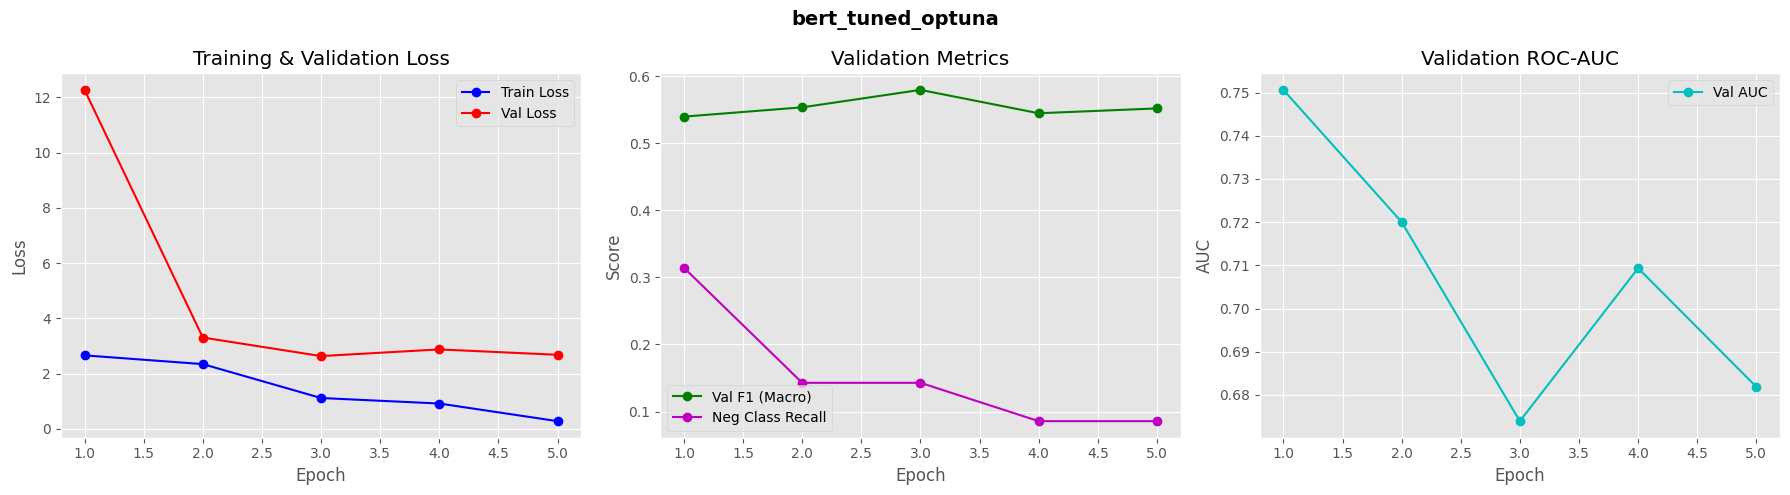

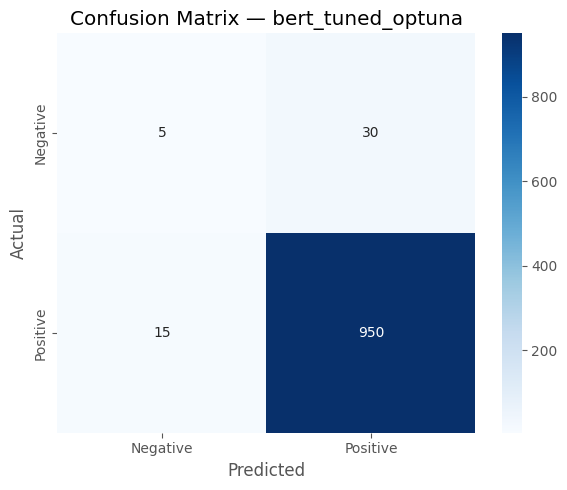

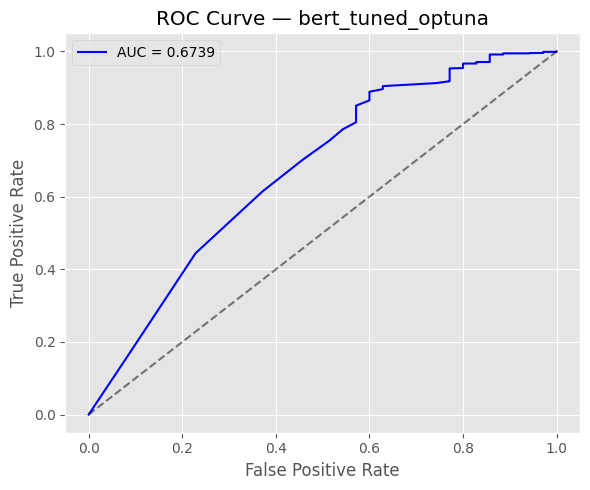

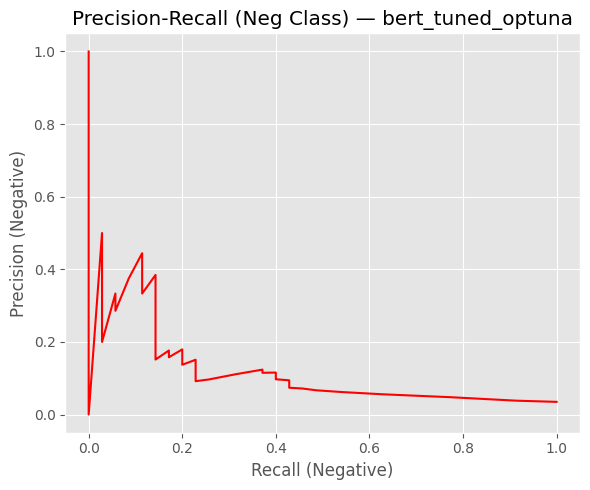


--- bert_tuned_optuna Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.25      0.14      0.18        35
    Positive       0.97      0.98      0.98       965

    accuracy                           0.95      1000
   macro avg       0.61      0.56      0.58      1000
weighted avg       0.94      0.95      0.95      1000

AUC: 0.6739


In [18]:
best_params = study.best_trial.params
results["bert_tuned"] = run_experiment(
    model_name="bert-base-uncased",
    experiment_name="bert_tuned_optuna",
    train_df=train_df, val_df=val_df,
    loss_type=best_params["loss_type"],
    lr=best_params["lr"],
    batch_size=best_params["batch_size"],
    dropout=best_params["dropout"],
    epochs=5, patience=3,
    max_len=best_params["max_len"]
)

##ABLATION STUDY


############################################################
# Experiment: ablation_no_dropout
# Model: bert-base-uncased | LR: 2e-05 | BS: 16
# Loss: focal | Dropout: 0.0 | MaxLen: 128
# Metadata: False
############################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: ablation_no_dropout
Epoch 1/5 (71s) | Train Loss: 0.0449 | Val Loss: 0.0292 | Val F1: 0.5161 | Neg Recall: 0.0857 | AUC: 0.7300
  -> Saved best model (F1=0.5161)
Epoch 2/5 (70s) | Train Loss: 0.0103 | Val Loss: 0.0363 | Val F1: 0.5591 | Neg Recall: 0.1143 | AUC: 0.7348
  -> Saved best model (F1=0.5591)
Epoch 3/5 (70s) | Train Loss: 0.0053 | Val Loss: 0.0411 | Val F1: 0.5432 | Neg Recall: 0.0857 | AUC: 0.6947
Epoch 4/5 (70s) | Train Loss: 0.0021 | Val Loss: 0.0484 | Val F1: 0.5623 | Neg Recall: 0.1143 | AUC: 0.6684
  -> Saved best model (F1=0.5623)
Epoch 5/5 (70s) | Train Loss: 0.0020 | Val Loss: 0.0466 | Val F1: 0.5304 | Neg Recall: 0.0571 | AUC: 0.6619


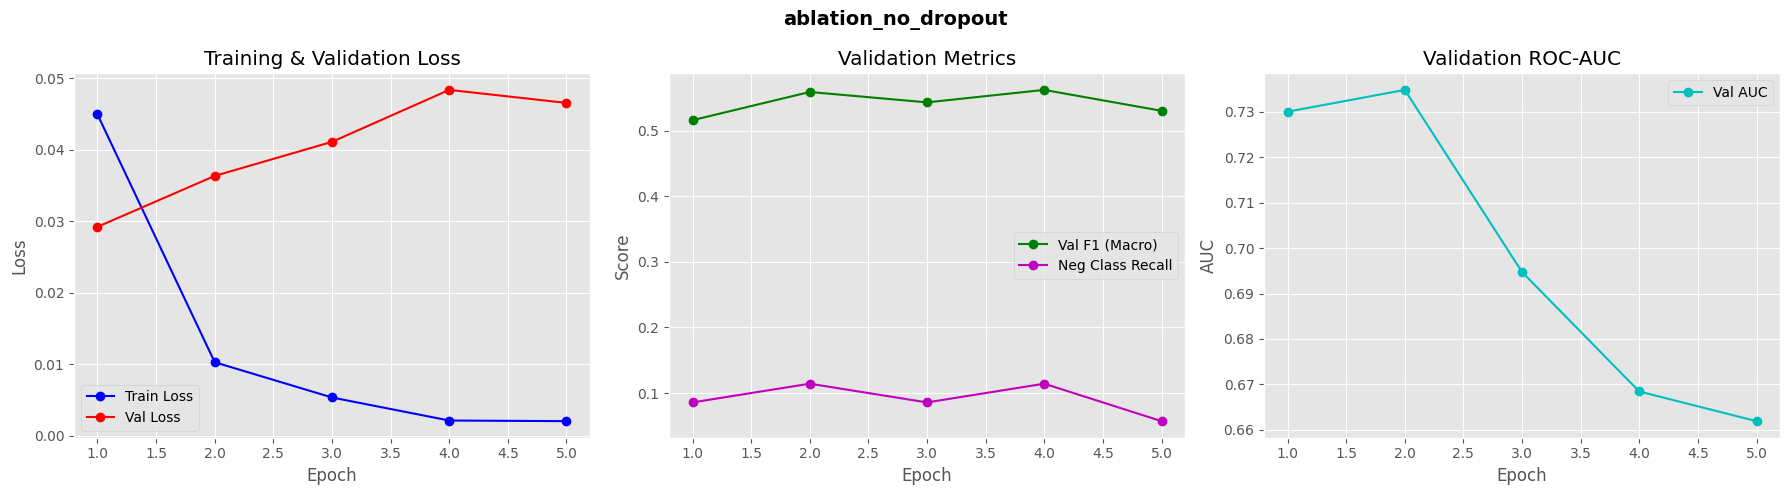

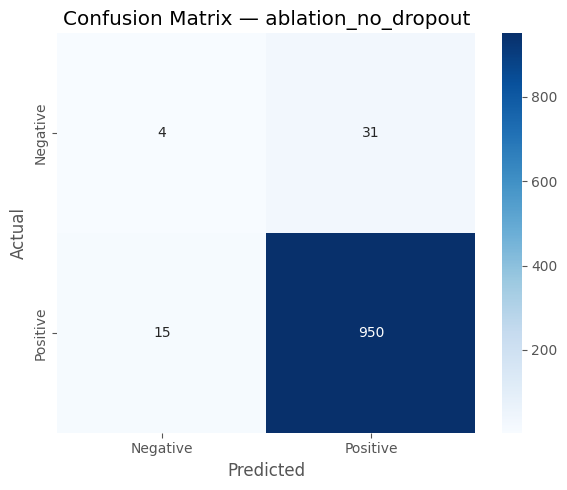

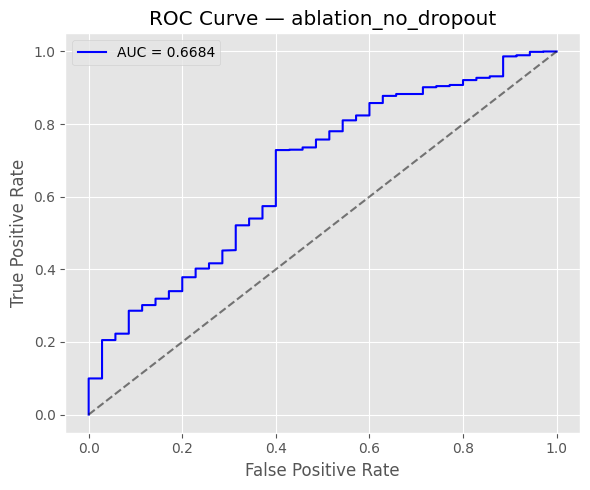

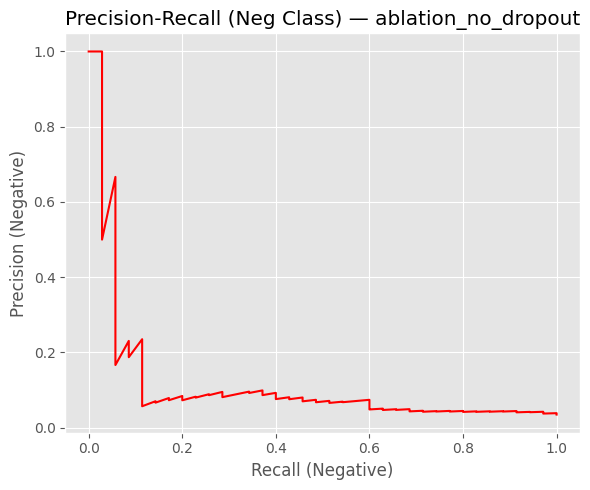


--- ablation_no_dropout Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.21      0.11      0.15        35
    Positive       0.97      0.98      0.98       965

    accuracy                           0.95      1000
   macro avg       0.59      0.55      0.56      1000
weighted avg       0.94      0.95      0.95      1000

AUC: 0.6684

############################################################
# Experiment: ablation_plain_bce
# Model: bert-base-uncased | LR: 2e-05 | BS: 16
# Loss: plain | Dropout: 0.3 | MaxLen: 128
# Metadata: False
############################################################


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training: ablation_plain_bce
Epoch 1/5 (73s) | Train Loss: 0.4436 | Val Loss: 0.3463 | Val F1: 0.5441 | Neg Recall: 0.2857 | AUC: 0.7130
  -> Saved best model (F1=0.5441)
Epoch 2/5 (78s) | Train Loss: 0.1151 | Val Loss: 0.4016 | Val F1: 0.5340 | Neg Recall: 0.1143 | AUC: 0.6959
Epoch 3/5 (94s) | Train Loss: 0.0520 | Val Loss: 0.3644 | Val F1: 0.5561 | Neg Recall: 0.1143 | AUC: 0.6618
  -> Saved best model (F1=0.5561)
Epoch 4/5 (92s) | Train Loss: 0.0295 | Val Loss: 0.3435 | Val F1: 0.5487 | Neg Recall: 0.0857 | AUC: 0.6853
Epoch 5/5 (85s) | Train Loss: 0.0167 | Val Loss: 0.3659 | Val F1: 0.5576 | Neg Recall: 0.1143 | AUC: 0.6779
  -> Saved best model (F1=0.5576)


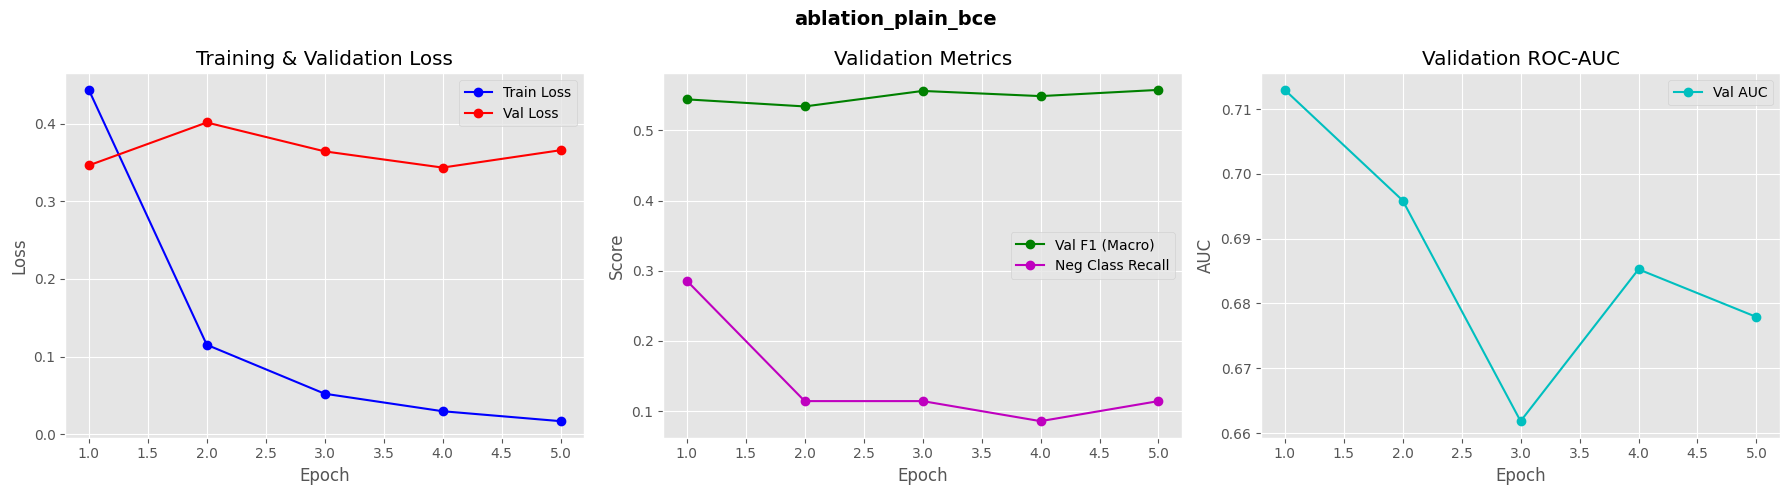

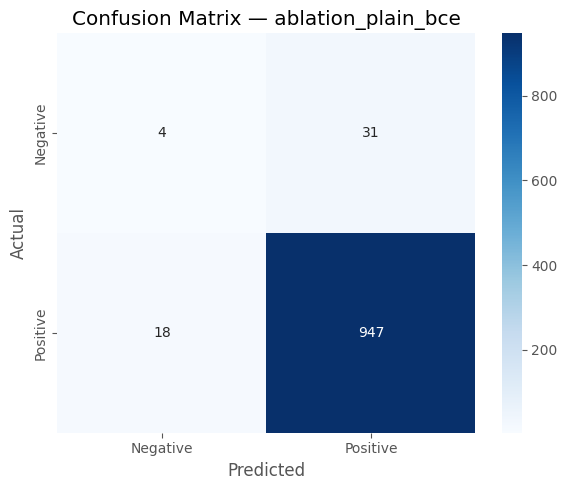

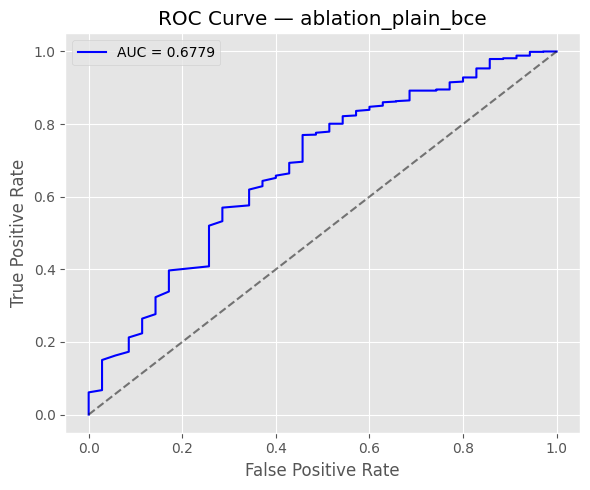

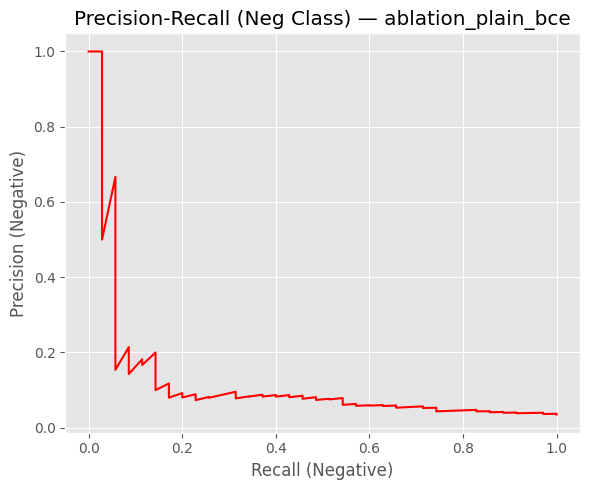


--- ablation_plain_bce Final Validation Report ---
              precision    recall  f1-score   support

    Negative       0.18      0.11      0.14        35
    Positive       0.97      0.98      0.97       965

    accuracy                           0.95      1000
   macro avg       0.58      0.55      0.56      1000
weighted avg       0.94      0.95      0.95      1000

AUC: 0.6779


In [19]:
# Ablation 1: No dropout
results["ablation_no_dropout"] = run_experiment(
    model_name="bert-base-uncased",
    experiment_name="ablation_no_dropout",
    train_df=train_df, val_df=val_df,
    loss_type="focal", lr=2e-5, batch_size=16,
    dropout=0.0, epochs=5, patience=3
)

# Ablation 2: Plain BCE (no class imbalance handling)
results["ablation_plain_bce"] = run_experiment(
    model_name="bert-base-uncased",
    experiment_name="ablation_plain_bce",
    train_df=train_df, val_df=val_df,
    loss_type="plain", lr=2e-5, batch_size=16,
    dropout=0.3, epochs=5, patience=3
)

##FINAL TEST SET EVALUATION (best model only!)


Best experiment: roberta_focal
Val F1 (macro): 0.6012


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



FINAL TEST SET RESULTS — roberta_focal
              precision    recall  f1-score   support

    Negative       0.10      0.20      0.13        41
    Positive       0.96      0.92      0.94       959

    accuracy                           0.89      1000
   macro avg       0.53      0.56      0.54      1000
weighted avg       0.93      0.89      0.91      1000

Test AUC: 0.5908


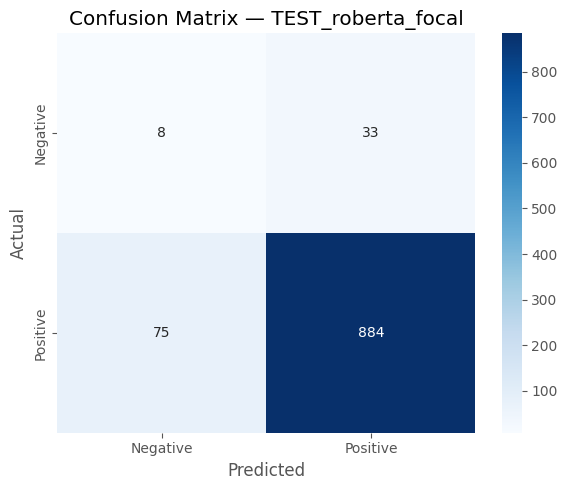

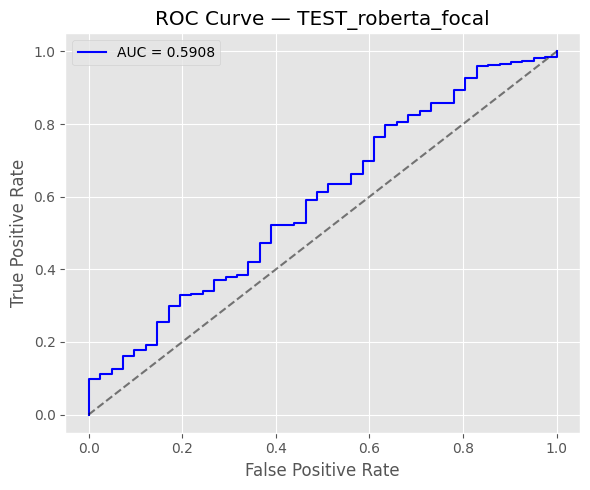

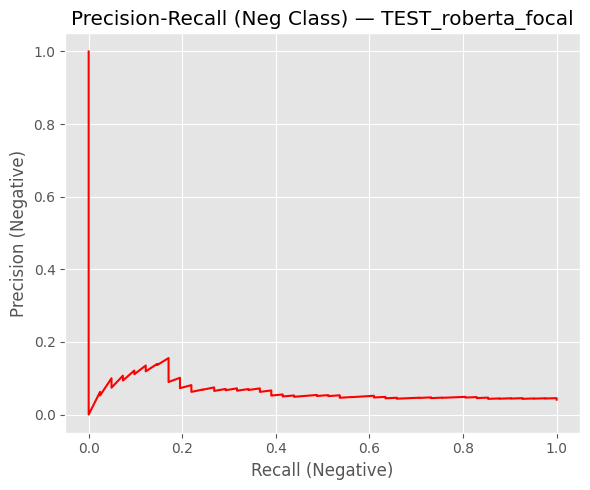

In [20]:
# Pick the best experiment by val F1
best_exp_name = max(results, key=lambda k: results[k]["val_metrics"]["f1_macro"])
best_result = results[best_exp_name]
print(f"\nBest experiment: {best_exp_name}")
print(f"Val F1 (macro): {best_result['val_metrics']['f1_macro']:.4f}")

# Load best model and evaluate on test set
best_config = best_result["config"]
tokenizer = AutoTokenizer.from_pretrained(best_result["model_name"])
test_ds = SteamReviewDataset(test_df, tokenizer, best_config["max_len"],
                             best_config["metadata"])
test_loader = DataLoader(test_ds, batch_size=best_config["batch_size"],
                         shuffle=False, num_workers=2)

n_meta = len(METADATA_COLS) if best_config["metadata"] else 0
model = BERTClassifier(best_result["model_name"], best_config["dropout"],
                       best_config["metadata"], n_meta).to(device)
model.load_state_dict(
    torch.load(OUTPUT_DIR / f"{best_exp_name}_best.pt", weights_only=True))

# Use a temporary engine for evaluation
dummy_criterion = FocalLoss()
engine = TrainingEngine(model, None, test_loader, None, None,
                        dummy_criterion, device, experiment_name="test_eval")
test_metrics = engine.evaluate(test_loader)

print(f"\n{'='*60}")
print(f"FINAL TEST SET RESULTS — {best_exp_name}")
print(f"{'='*60}")
print(test_metrics["report_str"])
print(f"Test AUC: {test_metrics['auc']:.4f}")

plot_confusion_matrix(test_metrics["confusion"], f"TEST_{best_exp_name}")
plot_roc_curve(test_metrics["labels"], test_metrics["probs"], f"TEST_{best_exp_name}")
plot_precision_recall_curve(test_metrics["labels"], test_metrics["probs"], f"TEST_{best_exp_name}")

##BASELINE COMPARISON (LogReg + TF-IDF)


=== Baseline: Logistic Regression + TF-IDF ===
              precision    recall  f1-score   support

    Negative       0.06      0.12      0.08        41
    Positive       0.96      0.92      0.94       959

    accuracy                           0.89      1000
   macro avg       0.51      0.52      0.51      1000
weighted avg       0.92      0.89      0.91      1000

Baseline AUC: 0.6722


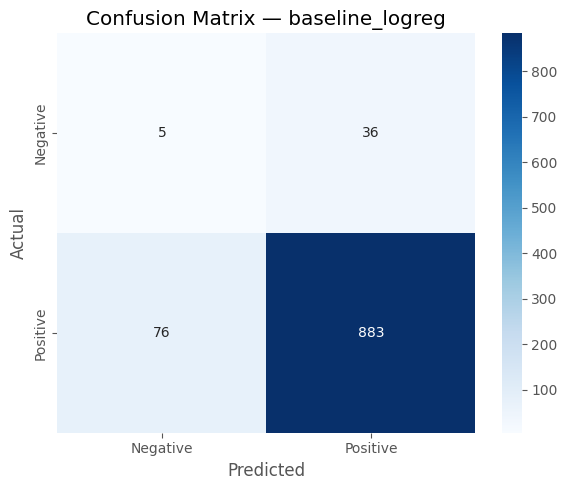

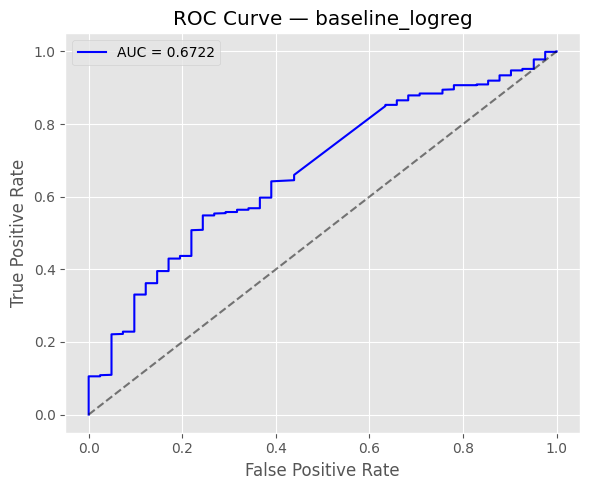

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("\n=== Baseline: Logistic Regression + TF-IDF ===")
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df["review"].fillna(""))
X_test_tfidf  = tfidf.transform(test_df["review"].fillna(""))

lr_model = LogisticRegression(class_weight="balanced", max_iter=1000)
lr_model.fit(X_train_tfidf, train_df["voted_up"])
lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]

print(classification_report(test_df["voted_up"], lr_preds,
                            target_names=["Negative", "Positive"]))
lr_auc = roc_auc_score(test_df["voted_up"], lr_probs)
print(f"Baseline AUC: {lr_auc:.4f}")

lr_cm = confusion_matrix(test_df["voted_up"], lr_preds)
plot_confusion_matrix(lr_cm, "baseline_logreg")
plot_roc_curve(test_df["voted_up"].values, lr_probs, "baseline_logreg")

##COMPARISON SUMMARY TABLE

In [22]:
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

summary_rows = []

# Add baseline
summary_rows.append({
    "Model": "LogReg + TF-IDF (Baseline)",
    "Loss": "N/A",
    "Val F1 (Macro)": "N/A",
    "Test Accuracy": accuracy_score(test_df["voted_up"], lr_preds),
    "Test F1 (Macro)": f1_score(test_df["voted_up"], lr_preds, average="macro"),
    "Test Neg Recall": classification_report(test_df["voted_up"], lr_preds, output_dict=True)["0"]["recall"],
    "Test AUC": lr_auc
})

# Add DL experiments (only those with test eval for best, val for others)
for name, res in results.items():
    vm = res["val_metrics"]
    row = {
        "Model": name,
        "Loss": res["config"]["loss"],
        "Val F1 (Macro)": vm["f1_macro"],
        "Test Accuracy": test_metrics["accuracy"] if name == best_exp_name else "—",
        "Test F1 (Macro)": test_metrics["f1_macro"] if name == best_exp_name else "—",
        "Test Neg Recall": test_metrics["report"]["Negative"]["recall"] if name == best_exp_name else "—",
        "Test AUC": test_metrics["auc"] if name == best_exp_name else "—"
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)


MODEL COMPARISON SUMMARY
                     Model         Loss Val F1 (Macro) Test Accuracy Test F1 (Macro) Test Neg Recall  Test AUC
LogReg + TF-IDF (Baseline)          N/A            N/A         0.888        0.511165        0.121951  0.672207
                bert_focal        focal       0.544534             —               —               —         —
                 bert_wbce weighted_bce       0.556738             —               —               —         —
             roberta_focal        focal       0.601221         0.892        0.535731        0.195122  0.590834
          distilbert_focal        focal       0.568211             —               —               —         —
               bert_fusion        focal       0.584868             —               —               —         —
                bert_tuned weighted_bce       0.579341             —               —               —         —
       ablation_no_dropout        focal       0.562255             —               —  

##COMBINED ROC CURVE (all models on one plot)

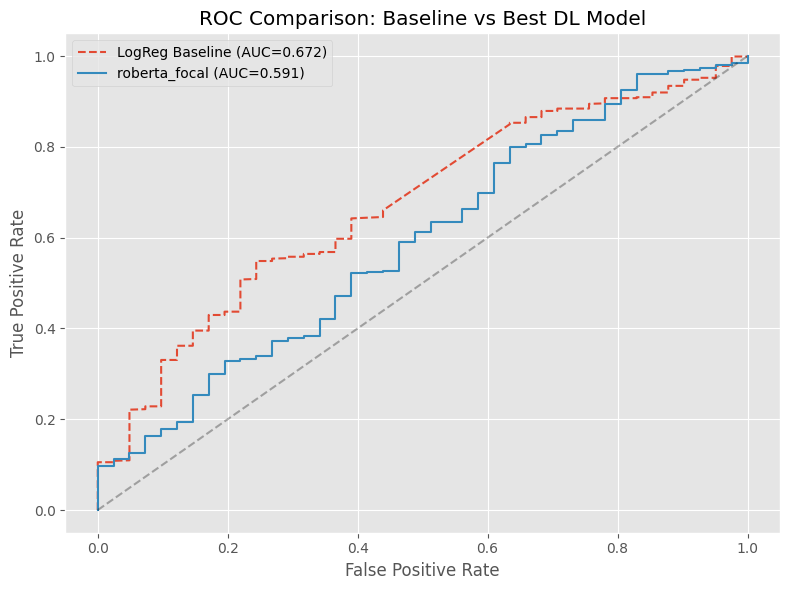


 All outputs saved to ./outputs/
Files: [PosixPath('outputs/ablation_plain_bce_pr.png'), PosixPath('outputs/bert_wbce_roc.png'), PosixPath('outputs/optuna_trial_0_best.pt'), PosixPath('outputs/model_comparison.csv'), PosixPath('outputs/bert_focal_cm.png'), PosixPath('outputs/optuna_results.csv'), PosixPath('outputs/ablation_no_dropout_roc.png'), PosixPath('outputs/ablation_plain_bce_cm.png'), PosixPath('outputs/distilbert_focal_pr.png'), PosixPath('outputs/roc_comparison.png'), PosixPath('outputs/bert_wbce_pr.png'), PosixPath('outputs/baseline_logreg_roc.png'), PosixPath('outputs/bert_tuned_optuna_pr.png'), PosixPath('outputs/bert_fusion_best.pt'), PosixPath('outputs/bert_wbce_best.pt'), PosixPath('outputs/optuna_trial_5_best.pt'), PosixPath('outputs/TEST_roberta_focal_roc.png'), PosixPath('outputs/ablation_plain_bce_roc.png'), PosixPath('outputs/optuna_trial_2_best.pt'), PosixPath('outputs/bert_focal_best.pt'), PosixPath('outputs/bert_focal_roc.png'), PosixPath('outputs/ablation_plai

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

# Baseline
fpr, tpr, _ = roc_curve(test_df["voted_up"], lr_probs)
ax.plot(fpr, tpr, "--", label=f"LogReg Baseline (AUC={lr_auc:.3f})")

# Best DL model on test
fpr, tpr, _ = roc_curve(test_metrics["labels"], test_metrics["probs"])
ax.plot(fpr, tpr, "-", label=f"{best_exp_name} (AUC={test_metrics['auc']:.3f})")

ax.plot([0,1], [0,1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Comparison: Baseline vs Best DL Model")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n All outputs saved to ./outputs/")
print("Files:", list(OUTPUT_DIR.iterdir()))